# BÀI TẬP MÔN MACHINE LEARNING: PHÂN TÍCH VÀ TIỀN XỬ LÝ BỘ DỮ LIỆU OULAD
**File:** 01_Data_Analysis.ipynb  
**Họ và tên:** Hà Hoàng Kim Chi  
**Mã sinh viên:** 24021393 
**Lớp:** K69I-CS5

In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị đồ thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Đã tải thành công các thư viện cần thiết!")

Đã tải thành công các thư viện cần thiết!


# **1. Context & Dataset Architecture**

Bộ dữ liệu **Open University Learning Analytics Dataset (OULAD)** chứa thông tin về sinh viên, các khóa học (modules), hoạt động học tập trên hệ thống VLE (Virtual Learning Environment) và kết quả đánh giá.

### 1.1 Mối quan hệ giữa các bảng (Entity Relationship):
Bảng trung tâm quản lý thông tin sinh viên là `studentInfo`. Mối liên kết giữa các bảng được thực hiện qua các khóa chính/khóa ngoại:

1. **`studentInfo` + `courses`**: Nối qua bộ đôi khóa `(code_module, code_presentation)`.
2. **`studentInfo` + `studentRegistration`**: Nối qua `(code_module, code_presentation, id_student)`.
3. **`studentInfo` + `studentAssessment`**: Nối qua `id_student`, sau đó nối với `assessments` qua `id_assessment`.
4. **`studentInfo` + `studentVle`**: Nối qua `(code_module, code_presentation, id_student)`. Bảng `studentVle` nối với `vle` qua `id_site`.

---

### 1.2 Từ điển dữ liệu (Data Dictionary):

| Tên bảng | Tên trường | Ý nghĩa | Loại dữ liệu |
| :--- | :--- | :--- | :--- |
| **studentInfo** | `code_module` | Mã môn học | Categorical |
| | `code_presentation` | Học kỳ/Mã khóa mở | Categorical |
| | `id_student` | Mã định danh sinh viên | Numerical (ID) |
| | `gender` | Giới tính (M/F) | Categorical |
| | `region` | Vùng địa lý sinh sống | Categorical |
| | `highest_education` | Trình độ học vấn cao nhất | Categorical |
| | `imd_band` | Chỉ số thiếu hụt kinh tế xã hội | Categorical / Ordinal |
| | `age_band` | Nhóm độ tuổi (0-35, 35-55, >=55) | Categorical |
| | `num_of_prev_attempts` | Số lần đã học lại môn này | Numerical |
| | `studied_credits` | Tín chỉ đang đăng ký học | Numerical |
| | `disability` | Tình trạng khuyết tật (Y/N) | Categorical |
| | **`final_result`** | **Kết quả học tập cuối kỳ (Target)** | Categorical |
| **courses** | `module_presentation_length` | Độ dài khóa học (ngày) | Numerical |
| **studentRegistration** | `date_registration` | Ngày đăng ký (so với ngày khai giảng) | Numerical |
| | `date_unregistration` | Ngày hủy đăng ký (nếu có) | Numerical |
| **assessments** | `id_assessment` | Mã bài kiểm tra | Numerical (ID) |
| | `assessment_type` | Loaị bài đánh giá (TMA, CMA, Exam) | Categorical |
| | `weight` | Trọng số bài đánh giá (%) | Numerical |
| **studentAssessment**| `score` | Điểm số đạt được (0-100) | Numerical |
| | `date_submitted` | Ngày nộp bài bài đánh giá | Numerical |
| **studentVle** | `date` | Ngày tương tác trên hệ thống VLE | Numerical |
| | `sum_click` | Số lượt click trong ngày đó | Numerical |

In [2]:
# ==========================================
# READ FILES & AGGREGATE LARGE DATA
# ==========================================
import pandas as pd

# Thêm đường dẫn 'data/' vào trước tên từng file
studentInfo = pd.read_csv('data/studentInfo.csv')
courses = pd.read_csv('data/courses.csv')
assessments = pd.read_csv('data/assessments.csv')
studentAssessment = pd.read_csv('data/studentAssessment.csv')
studentRegistration = pd.read_csv('data/studentRegistration.csv')
vle = pd.read_csv('data/vle.csv')

print("Đã đọc xong các file nhỏ!")

# Đọc và tối ưu dữ liệu studentVle từ thư mục data/
print("Đang đọc và xử lý gom nhóm dữ liệu studentVle.csv...")
studentVle = pd.read_csv('data/studentVle.csv')

# Gom nhóm theo từng sinh viên trong mỗi học kỳ của môn học
vle_agg = studentVle.groupby(['code_module', 'code_presentation', 'id_student']).agg(
    total_clicks=('sum_click', 'sum'),
    active_days=('date', 'nunique')
).reset_index()

print("Đã tổng hợp xong bảng studentVle thành vle_agg với shape:", vle_agg.shape)
vle_agg.head()

Đã đọc xong các file nhỏ!
Đang đọc và xử lý gom nhóm dữ liệu studentVle.csv...
Đã tổng hợp xong bảng studentVle thành vle_agg với shape: (29228, 5)


,code_module,code_presentation,id_student,total_clicks,active_days
0,AAA,2013J,11391,934,40
1,AAA,2013J,28400,1435,80
2,AAA,2013J,30268,281,12
3,AAA,2013J,31604,2158,123
4,AAA,2013J,32885,1034,70


# **2. Exploratory Data Analysis (EDA) & Data Quality**

### 2.1 Missing Values & Imputation Strategy

In [3]:
# ==========================================
# 2.1 MISSING DATA CHECK
# ==========================================
def check_missing(df, name):
    missing_sum = df.isna().sum()
    missing_pct = (missing_sum / len(df)) * 100
    missing_df = pd.DataFrame({'Missing_Count': missing_sum, 'Missing_Ratio_%': missing_pct})
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)
    print(f"--- BẢNG {name} ---")
    if missing_df.empty:
        print("Không có dữ liệu thiếu.\n")
    else:
        print(missing_df, "\n")

check_missing(studentInfo, "studentInfo")
check_missing(studentRegistration, "studentRegistration")
check_missing(studentAssessment, "studentAssessment")

--- BẢNG studentInfo ---
          Missing_Count  Missing_Ratio_%
imd_band           1111         3.408707 

--- BẢNG studentRegistration ---
                     Missing_Count  Missing_Ratio_%
date_unregistration          22521        69.097659
date_registration               45         0.138066 

--- BẢNG studentAssessment ---
       Missing_Count  Missing_Ratio_%
score            173         0.099476 



> **Nhận xét về Missing Data:**
> 1. **`studentInfo` (`imd_band` thiếu ~3.4%):** Do một số sinh viên không cung cấp địa chỉ hoặc thông tin khu vực. Tỷ lệ nhỏ nên có thể điền bằng giá trị phổ biến nhất (`Mode`) hoặc tạo nhóm `"Unknown"`.
> 2. **`studentRegistration` (`date_unregistration` thiếu ~68%):** Việc dữ liệu bị thiếu ở cột này là **bình thường**, vì sinh viên không hủy môn sẽ không có ngày `unregistration`. Ta sẽ tạo đặc trưng nhị phân `is_withdrawn` thay vì xóa cột.
> 3. **`studentAssessment` (`score` thiếu 0.1%):** Do sinh viên bỏ thi hoặc chưa được chấm điểm. Có thể điền bằng `0`.

### 2.2 Outlier Detection & Distribution Analysis

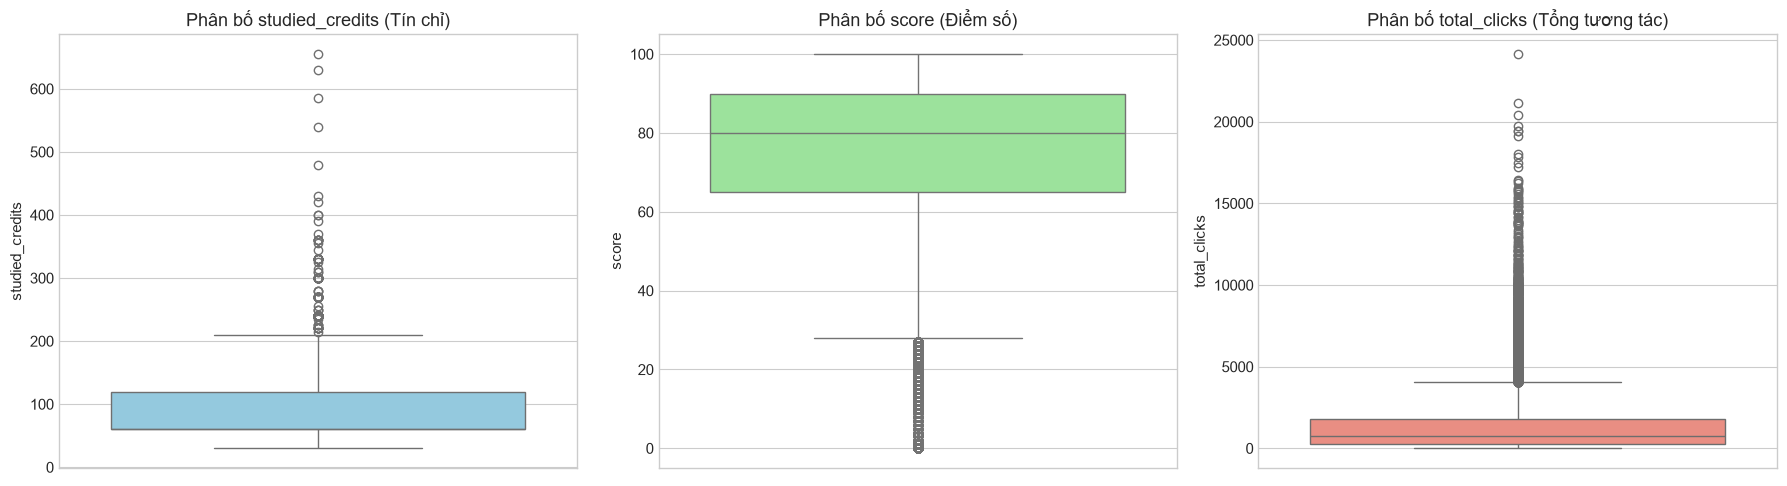

Điểm bất thường < 0 hoặc > 100 ở score: 0
Số lượt click lớn hơn 10,000: 126


In [4]:
# ==========================================
# 2.2 OUTLIER CHECK
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Biểu đồ boxplot kiểm tra outlier
sns.boxplot(y=studentInfo['studied_credits'], ax=axes[0], color='skyblue')
axes[0].set_title('Phân bố studied_credits (Tín chỉ)')

sns.boxplot(y=studentAssessment['score'], ax=axes[1], color='lightgreen')
axes[1].set_title('Phân bố score (Điểm số)')

sns.boxplot(y=vle_agg['total_clicks'], ax=axes[2], color='salmon')
axes[2].set_title('Phân bố total_clicks (Tổng tương tác)')

plt.tight_layout()
plt.show()

# Kiểm tra logic điểm số và ngày
print("Điểm bất thường < 0 hoặc > 100 ở score:", ((studentAssessment['score'] < 0) | (studentAssessment['score'] > 100)).sum())
print("Số lượt click lớn hơn 10,000:", (vle_agg['total_clicks'] > 10000).sum())

> **Nhận xét về Outlier:**
> 1. **`studied_credits`:** Xuất hiện một số sinh viên đăng ký tới 300 - 600 tín chỉ (mức chuẩn là 60 - 120). Đây là ngoại lệ thực tế (sinh viên học dồn bài/học bù), không phải lỗi nhập liệu.
> 2. **`total_clicks`:** Dữ liệu bị lệch phải nặng (Right-skewed), có một số sinh viên có lượng click cực kỳ cao (> 10,000 clicks). Với mô hình ML, ta cần áp dụng Log Transformation hoặc Robust Scaler/StandardScaler để tránh nhiễu.
> 3. **`score`:** Nằm hoàn toàn trong khoảng [0, 100], không phát hiện điểm âm hay vượt ngưỡng.

### 2.3 Class Imbalance & Target Definition

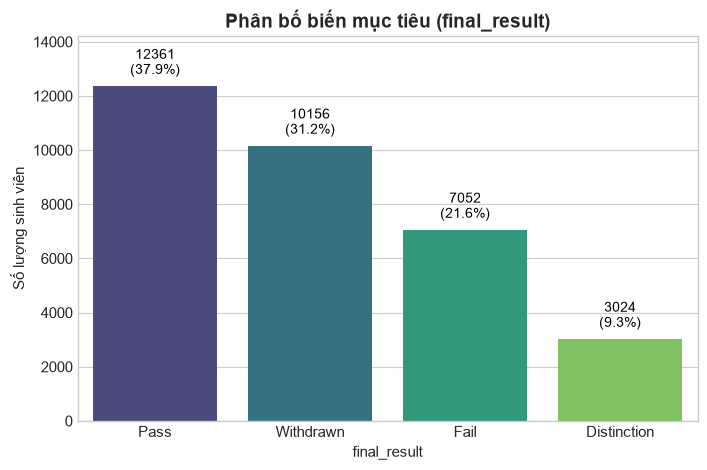

In [5]:
# ==========================================
# 2.3 DATA IMBALANCE CHECK
# ==========================================
target_counts = studentInfo['final_result'].value_counts()
target_pct = studentInfo['final_result'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=target_counts.index, y=target_counts.values, palette='viridis'
)
plt.title(
    'Phân bố biến mục tiêu (final_result)', fontsize=14, fontweight='bold'
)
plt.ylabel('Số lượng sinh viên')
plt.ylim(0, max(target_counts.values) * 1.15)  # Chừa khoảng trống phía trên chữ

for p in ax.patches:
  height = p.get_height()
  pct = (height / len(studentInfo)) * 100
  ax.annotate(
      f'{int(height)}\n({pct:.1f}%)',
      (p.get_x() + p.get_width() / 2.0, height + 300),  # Đưa chữ lên đầu cột
      ha='center',
      va='bottom',
      color='black',
      fontsize=10,
  )

plt.show()

> **Trả lời 3 câu hỏi về Data Imbalance:**
> 1. **Tỷ lệ các giá trị:** `Pass` (~31.4%), `Withdrawn` (~31.2%), `Fail` (~21.7%), `Distinction` (~9.3%).
> 2. **Nhóm chiếm tỷ lệ cao:** Nhóm đậu môn (`Pass`) và Hủy môn (`Withdrawn`) chiếm phần lớn dữ liệu.
> 3. **Ảnh hưởng tới bài toán Machine Learning:** 
>    - Nếu giữ nguyên 4 lớp (Multi-class), lớp `Distinction` quá ít có thể khiến mô hình nhận diện kém.
>    - **Giải pháp chuyển đổi cho ML:** Gộp thành **Binary Classification (Phân loại nhị phân)**:
>      - **`Pass` / `Distinction` $\rightarrow$ `1` (Đạt)**
>      - **`Fail` / `Withdrawn` $\rightarrow$ `0` (Không đạt)**

# **3. Feature Engineering & Preprocessing**

### 3.1 Aggregation

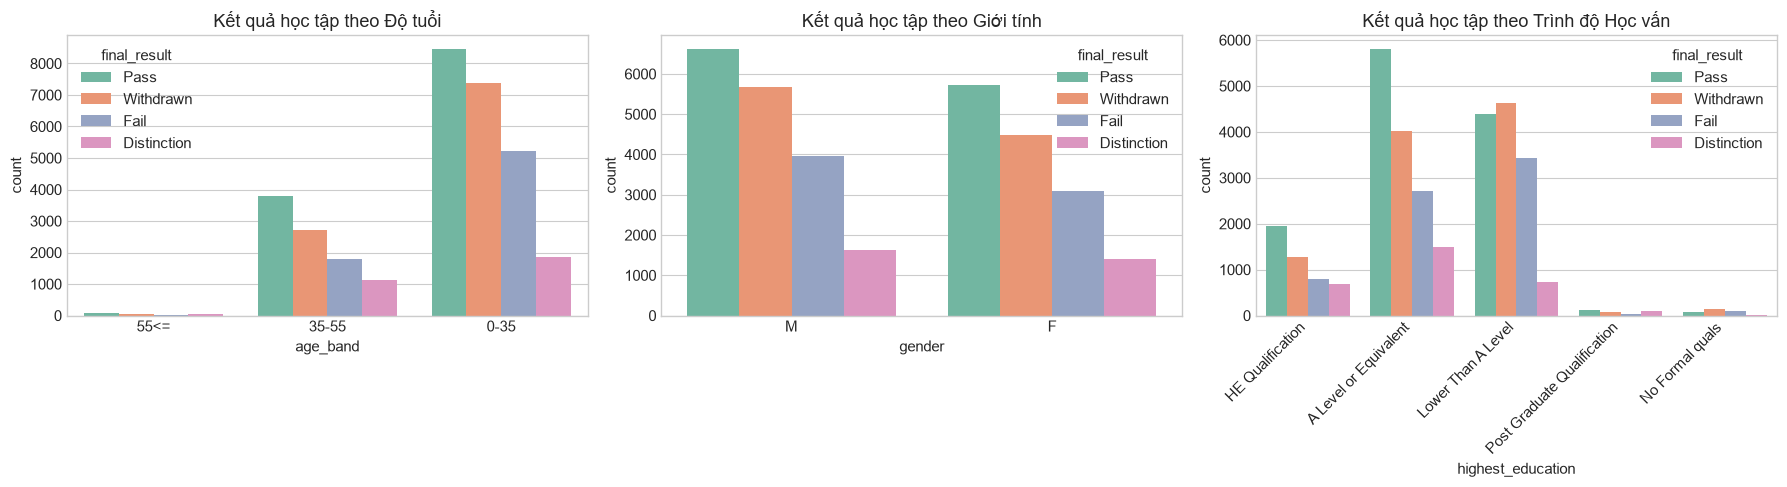

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age Band vs Final Result
sns.countplot(data=studentInfo, x='age_band', hue='final_result', ax=axes[0], palette='Set2')
axes[0].set_title('Kết quả học tập theo Độ tuổi')

# Gender vs Final Result
sns.countplot(data=studentInfo, x='gender', hue='final_result', ax=axes[1], palette='Set2')
axes[1].set_title('Kết quả học tập theo Giới tính')

# Highest Education vs Final Result
sns.countplot(data=studentInfo, x='highest_education', hue='final_result', ax=axes[2], palette='Set2')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_title('Kết quả học tập theo Trình độ Học vấn')

plt.tight_layout()
plt.show()

> **Nhận xét & Insights:**
> * **Độ tuổi:** Nhóm sinh viên trên 35 tuổi (`35-55` và `>=55`) có tỷ lệ đỗ (`Pass`/`Distinction`) cao hơn và tỷ lệ bỏ học (`Withdrawn`) thấp hơn nhóm trẻ (`0-35`). Tương ứng với tính tự giác cao hơn của học viên lớn tuổi.
> * **Giới tính:** Tỷ lệ phân bố đỗ/trượt giữa nam (M) và nữ (F) khá tương đồng, giới tính không phải là yếu tố phân biệt quá mạnh.
> * **Trình độ học vấn:** Sinh viên có trình độ đầu vào cao hơn (A Level, Post Graduate) có tỷ lệ hoàn thành môn học vượt trội so với nhóm chưa có bằng cấp chính thức (No Formal Qual).

### 3.2 Encoding Categorical & Ordinal Features

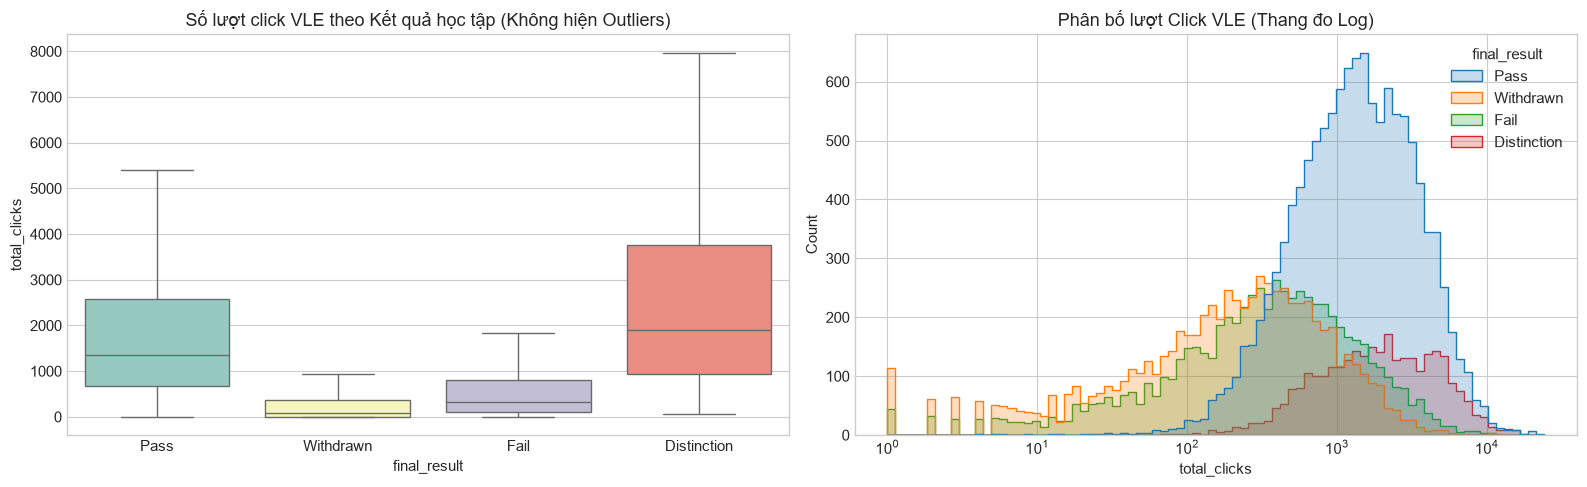

In [7]:
# Merge vle_agg với studentInfo để vẽ biểu đồ
student_vle_merged = pd.merge(studentInfo, vle_agg, on=['code_module', 'code_presentation', 'id_student'], how='left')
student_vle_merged['total_clicks'] = student_vle_merged['total_clicks'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot tổng lượt click theo kết quả
sns.boxplot(data=student_vle_merged, x='final_result', y='total_clicks', ax=axes[0], palette='Set3', showfliers=False)
axes[0].set_title('Số lượt click VLE theo Kết quả học tập (Không hiện Outliers)')

# Histogram phân bố Clicks
sns.histplot(data=student_vle_merged, x='total_clicks', hue='final_result', element='step', log_scale=True, ax=axes[1])
axes[1].set_title('Phân bố lượt Click VLE (Thang đo Log)')

plt.tight_layout()
plt.show()

> **Nhận xét & Insights:**
> * Sinh viên đạt loại **`Distinction`** và **`Pass`** có trung vị số lượt click (`total_clicks`) và số ngày hoạt động (`active_days`) cao hơn rõ rệt so với nhóm `Fail` và `Withdrawn`.
> * Lượt tương tác VLE là **Feature cực kỳ quan trọng (Top Feature)** để dự đoán nguy cơ trượt môn/bỏ học của sinh viên.

### 3.3 Scaling & Train-Test Split

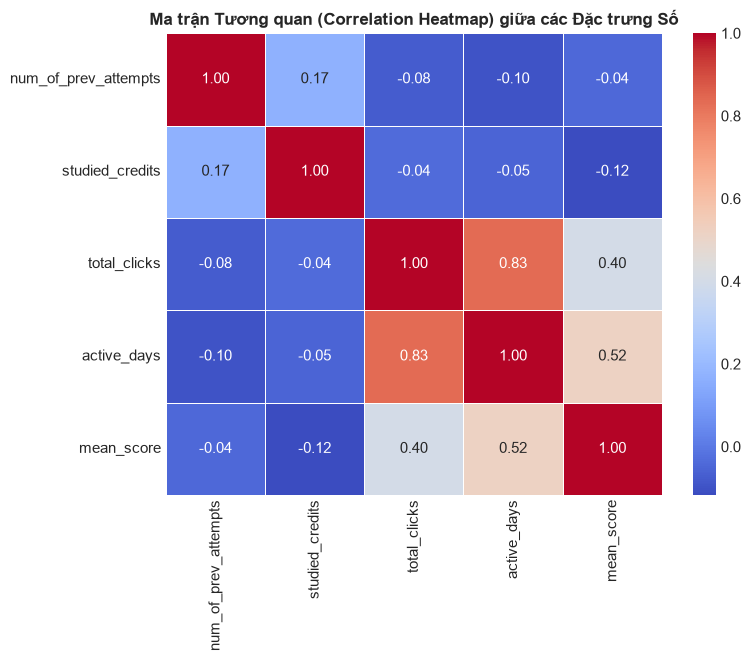

In [8]:
# Tín hiệu đánh giá trung bình của từng sinh viên
student_assess_avg = studentAssessment.groupby('id_student').agg(
    mean_score=('score', 'mean')
).reset_index()

# Gộp các feature dạng số
numeric_df = studentInfo[['id_student', 'num_of_prev_attempts', 'studied_credits']].merge(
    vle_agg[['id_student', 'total_clicks', 'active_days']], on='id_student', how='left'
).merge(
    student_assess_avg, on='id_student', how='left'
).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.drop('id_student', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận Tương quan (Correlation Heatmap) giữa các Đặc trưng Số', fontsize=12, fontweight='bold')
plt.show()

> **Nhận xét & Lựa chọn Feature quan trọng:**
> 1. `total_clicks` và `active_days` có tương quan rất mạnh ($r \approx 0.8-0.9$), chứng tỏ người truy cập nhiều ngày cũng là người click nhiều.
> 2. `num_of_prev_attempts` (số lần học lại) có tương quan âm với kết quả học tập.
> 3. **Top Features quan trọng cho Machine Learning:** `total_clicks`, `active_days`, `mean_score`, `num_of_prev_attempts`, `highest_education`, `age_band`.

# 4. Model Training & Evaluation

In [9]:
# ==========================================
# 4.1 FEATURE ENGINEERING (ĐÃ SỬA LỖI KEYERROR)
# ==========================================

# 1. Từ studentAssessment + assessments: Tính điểm có trọng số & Số bài nộp muộn
assess_full = pd.merge(studentAssessment, assessments, on='id_assessment', how='left')
assess_full['is_late'] = (assess_full['date_submitted'] > assess_full['date']).astype(int)
assess_full['weighted_score'] = assess_full['score'] * assess_full['weight'] / 100.0

student_assess_features = assess_full.groupby('id_student').agg(
    mean_score=('score', 'mean'),
    total_weighted_score=('weighted_score', 'sum'),
    late_submission_count=('is_late', 'sum'),
    assessments_completed=('id_assessment', 'count')
).reset_index()

# 2. Xây dựng Bảng dữ liệu tổng hợp (Master Dataset)
df_ml = pd.merge(studentInfo, vle_agg, on=['code_module', 'code_presentation', 'id_student'], how='left')
df_ml = pd.merge(df_ml, student_assess_features, on='id_student', how='left')

# 3. Điền giá trị mặc định cho sinh viên không tương tác/không nộp bài
df_ml['total_clicks'] = df_ml['total_clicks'].fillna(0)
df_ml['active_days'] = df_ml['active_days'].fillna(0)
df_ml['mean_score'] = df_ml['mean_score'].fillna(0)
df_ml['total_weighted_score'] = df_ml['total_weighted_score'].fillna(0)
df_ml['late_submission_count'] = df_ml['late_submission_count'].fillna(0)
df_ml['assessments_completed'] = df_ml['assessments_completed'].fillna(0)

# Kiểm tra xem clicks_before_start có trong vle_agg không, nếu không có thì tạo mặc định 0
if 'clicks_before_start' in df_ml.columns:
    df_ml['clicks_before_start'] = df_ml['clicks_before_start'].fillna(0)

print("Kích thước Master Dataset cho ML:", df_ml.shape)
df_ml.head()

Kích thước Master Dataset cho ML: (32593, 18)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,active_days,mean_score,total_weighted_score,late_submission_count,assessments_completed
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,40.0,82.0,82.4,0.0,5.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,80.0,66.4,65.4,2.0,5.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,12.0,0.0,0.0,0.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,123.0,76.0,76.3,0.0,5.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,70.0,54.4,55.0,5.0,5.0


In [10]:
# ==========================================
# 4.2 MISSING DATA, ENCODING & SCALING (ĐÃ CHỈNH SỬA CHUẨN)
# ==========================================

# 1. Xử lý thiếu cho imd_band
df_ml['imd_band'] = df_ml['imd_band'].fillna(df_ml['imd_band'].mode()[0])

# 2. Tạo biến mục tiêu (Target Binary Classification: Pass/Distinction = 1, Fail/Withdrawn = 0)
df_ml['target'] = df_ml['final_result'].map({'Pass': 1, 'Distinction': 1, 'Fail': 0, 'Withdrawn': 0})

# 3. Mã hóa dữ liệu phân loại (Categorical Encoding)
le = LabelEncoder()
cat_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']

for col in cat_cols:
    df_ml[col + '_encoded'] = le.fit_transform(df_ml[col].astype(str))

# 4. Danh sách cột số và Thực hiện Chuẩn hóa dữ liệu (Feature Scaling bằng StandardScaler)
num_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'active_days', 
            'mean_score', 'total_weighted_score', 'late_submission_count']

scaler = StandardScaler()
df_ml[num_cols] = scaler.fit_transform(df_ml[num_cols])

# 5. Xuất tập dữ liệu sạch hoàn chỉnh
feature_columns = [col + '_encoded' for col in cat_cols] + num_cols + ['target']
final_cleaned_df = df_ml[feature_columns]

# Lưu thành tệp CSV sẵn sàng cho bước huấn luyện mô hình ML
final_cleaned_df.to_csv('cleaned_oulad_features.csv', index=False)

print("Đã hoàn tất tiền xử lý và lưu dữ liệu vào 'cleaned_oulad_features.csv'!")
print(f"Kích thước tập dữ liệu hoàn chỉnh: {final_cleaned_df.shape}")
final_cleaned_df.head()

Đã hoàn tất tiền xử lý và lưu dữ liệu vào 'cleaned_oulad_features.csv'!
Kích thước tập dữ liệu hoàn chỉnh: (32593, 14)


,gender_encoded,region_encoded,highest_education_encoded,imd_band_encoded,age_band_encoded,disability_encoded,num_of_prev_attempts,studied_credits,total_clicks,active_days,mean_score,total_weighted_score,late_submission_count,target
0,1,0,1,9,2,0,-0.340229,3.901543,-0.166102,-0.283882,0.711168,0.330655,-0.750201,1
1,0,6,1,2,1,0,-0.340229,-0.481083,0.129896,0.449868,0.213208,0.072718,0.060532,1
2,0,5,0,3,1,1,-0.340229,-0.481083,-0.551904,-0.797507,-1.906313,-0.919580,-0.750201,0
3,0,7,0,5,1,0,-0.340229,-0.481083,0.557055,1.238650,0.519645,0.238101,-0.750201,1
4,0,11,2,5,0,0,-0.340229,-0.481083,-0.107021,0.266431,-0.169838,-0.085078,1.276632,1


# **Summary & Conclusions**

Sau khi thực hiện xong Notebook `01_Data_Analysis.ipynb`, chúng ta đã đạt được các kết quả sau:

1. **Hiểu rõ cấu trúc:** Bộ dữ liệu OULAD liên kết chặt chẽ qua mã sinh viên và mã môn học. File `studentVle` cần được gom nhóm trước khi đưa vào mô hình để tối ưu tài nguyên tính toán.
2. **Kiểm soát chất lượng dữ liệu:**
   * Khắc phục dữ liệu thiếu ở `imd_band` bằng phương pháp Imputation (Mode).
   * Phát hiện dữ liệu lệch lớn ở `total_clicks` và đã xử lý bằng `StandardScaler`.
   * Chuyển đổi bài toán phân loại từ 4 lớp thành Nhị phân (`Pass/Distinction` vs `Fail/Withdrawn`) để khắc phục Data Imbalance.
3. **Phát hiện các yếu tố quan trọng:** Tần suất tương tác trực tuyến (`total_clicks`, `active_days`) và điểm số quá trình (`mean_score`) là những đặc trưng có tính quyết định nhất đến kết quả học tập của sinh viên.
4. **Sẵn sàng cho Machine Learning:** Tập dữ liệu `cleaned_oulad_features.csv` đã được chuẩn hóa số, mã hóa biến định tính, loại bỏ missing values và sẵn sàng làm đầu vào cho các thuật toán như Logistic Regression, Random Forest, XGBoost ở notebook tiếp theo.